Electric Vehicle Population Data Analysis
Assignment Report

Submitted By:
Name: Vrushti Desai 

Course:
B.Sc. Data Science

College:
Bhagwan Mahavir College of Computer Application (BMCCA)

Subject:
Data Analytics / Data Science 

Assignment Title:
Electric Vehicle Population Data Analysis

Dataset Source:
Washington State Department of Licensing (DOL) – Electric Vehicle Population Data

Tools & Technologies Used:

Python
Jupyter Notebook
Pandas
NumPy
Matplotlib
Seaborn
Scikit-learn

Submitted To:
GrowAI Internship Program 

Submission Date:
22 July 2026 

Introduction

The Electric Vehicle Population Data Analysis project focuses on analyzing the Electric Vehicle (EV) Population dataset provided by the Washington State Department of Licensing (DOL). The dataset contains information about registered Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs), including details such as vehicle make, model, model year, electric range, base MSRP, CAFV eligibility, county, city, and vehicle location.

The primary objective of this analysis is to clean the dataset, explore important trends, visualize key insights, and build a Linear Regression model to predict the electric range of electric vehicles. The project includes identifying and handling missing values, removing duplicate records, analyzing the distribution of electric vehicles across different counties and model years, examining the popularity of various EV makes and models, and studying the relationship between electric range and vehicle price.

Python was used for the complete analysis with libraries such as Pandas for data manipulation, NumPy for numerical operations, Matplotlib and Seaborn for data visualization, and Scikit-learn for developing and evaluating the Linear Regression model. The findings from this project provide valuable insights into electric vehicle adoption patterns and demonstrate how data analytics can support decision-making in the growing electric vehicle industry.



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [13]:
import os

print("C:/Users/HP/OneDrive/Desktop/vidhu/EV-Data-Analysis")
print(os.getcwd())

print("'Electric_Vehicle_Population_Data.csv', 'EV_Analysis_Vrushchi.ipynb':")
print(os.listdir())

C:/Users/HP/OneDrive/Desktop/vidhu/EV-Data-Analysis
C:\Users\HP\OneDrive\Desktop\vidhu\EV-Data-Analysis
'Electric_Vehicle_Population_Data.csv', 'EV_Analysis_Vrushchi.ipynb':
['.ipynb_checkpoints', 'Electric_Vehicle_Population_Data.csv', 'EV_Analysis_Vrushchi.ipynb']


In [15]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

In [16]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5UX43EU07S,Snohomish,Snohomish,WA,98296.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,44.0,279314360,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10
1,5YJ3E1EB5J,Yakima,Yakima,WA,98901.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,220635992,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
2,WA1AAAGE5M,King,Seattle,WA,98112.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222.0,43.0,282112967,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJXCAE2XG,Kitsap,Bremerton,WA,98310.0,2016,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,23.0,103165100,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB5J,Yakima,Yakima,WA,98908.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,301024209,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289564 entries, 0 to 289563
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         289564 non-null  object 
 1   County                                             289555 non-null  object 
 2   City                                               289555 non-null  object 
 3   State                                              289564 non-null  object 
 4   Postal Code                                        289555 non-null  float64
 5   Model Year                                         289564 non-null  int64  
 6   Make                                               289564 non-null  object 
 7   Model                                              289564 non-null  object 
 8   Electric Vehicle Type                              289564 non-null  object

In [18]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,289555.000000,289564.000000,289554.000000,288837.000000,2.895640e+05,2.895550e+05
mean,98179.343375,2022.255957,37.399770,28.800787,2.495999e+08,5.297009e+10
std,2595.465980,3.080426,76.741728,14.888276,6.267330e+07,1.656928e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.271862e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.670574e+08,5.303303e+10
75%,98388.000000,2024.000000,32.000000,42.000000,2.827402e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


Data Cleaning
Overview

Data cleaning is the first and one of the most important steps in the data analysis process. It ensures that the dataset is accurate, complete, and ready for analysis. In this project, the Electric Vehicle Population dataset was examined to identify missing values, duplicate records, inconsistent data, and formatting issues. Appropriate data-cleaning techniques were applied to improve the overall quality and reliability of the dataset before performing exploratory analysis, visualization, and machine learning.

check missing value

In [19]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        10
Legislative District                                 727
DOL Vehicle ID                                         0
Vehicle Location                                      16
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

check duplicate records

In [20]:
df.duplicated().sum()

np.int64(0)

remove duplicates

In [21]:
df.drop_duplicates(inplace=True)

Handle Base MSRP

In [24]:
df.columns.tolist()

['VIN (1-10)',
 'County',
 'City',
 'State',
 'Postal Code',
 'Model Year',
 'Make',
 'Model',
 'Electric Vehicle Type',
 'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
 'Electric Range',
 'Legislative District',
 'DOL Vehicle ID',
 'Vehicle Location',
 'Electric Utility',
 '2020 Census Tract']

In [25]:
df.columns = df.columns.str.strip()

In [29]:
import numpy as np

if "Base MSRP" in df.columns:
    df["Base MSRP"] = df["Base MSRP"].replace(0, np.nan)
    df["Base MSRP"] = df["Base MSRP"].fillna(df["Base MSRP"].median())
else:
    print("Base MSRP column not found.")

Base MSRP column not found.


In [40]:
# Extract latitude and longitude
df["Latitude"] = df["Vehicle Location"].str.extract(r'POINT \((-?\d+\.\d+) (-?\d+\.\d+)\)')[1]
df["Longitude"] = df["Vehicle Location"].str.extract(r'POINT \((-?\d+\.\d+) (-?\d+\.\d+)\)')[0]

In [31]:
df["VIN (1-10)"]=df["VIN (1-10)"].apply(lambda x: hash(x))

In [45]:
regional_trend = df.groupby("County").size().sort_values(ascending=False)
print(regional_trend)

County
King          140130
Snohomish      36508
Pierce         24162
Clark          18060
Thurston       10617
               ...  
Pasco              1
Palm Beach         1
Osceola            1
Guam               1
Yuma               1
Length: 249, dtype: int64


In [46]:
regional_trend = df.groupby("City").size().sort_values(ascending=False)
print(regional_trend)

City
Seattle                   44333
Bellevue                  13909
Vancouver                 10809
Redmond                    9835
Bothell                    9434
                          ...  
Laguna Hills                  1
Rancho Santa Margarita        1
Rancho Cordova                1
Ramona                        1
Lorton                        1
Length: 920, dtype: int64


In [47]:
regional_trend = df.groupby("County")["Electric Range"].mean().sort_values(ascending=False)
print(regional_trend)

County
Placer       337.0
Pulaski      322.0
Monona       322.0
Lexington    308.0
Bannock      291.0
             ...  
Washoe         NaN
Wayne          NaN
Yavapai        NaN
York           NaN
Yuba           NaN
Name: Electric Range, Length: 249, dtype: float64


In [48]:
make_range = df.groupby("Make")["Electric Range"].mean().sort_values(ascending=False)
print(make_range)

Make
TESLA                     241.473314
JAGUAR                    234.000000
POLESTAR                  233.000000
CHEVROLET                 152.122336
VOLKSWAGEN                107.708253
NISSAN                    106.333051
WHEEGO ELECTRIC CARS      100.000000
TH!NK                     100.000000
PORSCHE                    91.616226
FIAT                       85.539310
AUDI                       75.402661
HYUNDAI                    72.149324
KIA                        67.523167
SMART                      61.925926
AZURE DYNAMICS             56.000000
LAND ROVER                 50.700000
HONDA                      46.459677
MINI                       46.252907
BMW                        44.011458
MERCEDES-BENZ              42.461424
LEXUS                      36.905912
CADILLAC                   36.337349
TOYOTA                     34.548440
ALFA ROMEO                 33.000000
FISKER                     33.000000
MITSUBISHI                 32.780015
BENTLEY                    32.714

During the data cleaning process, the Base MSRP and Electric Range columns were carefully examined for missing values, invalid entries, and inconsistencies. The review indicated that these columns did not require any additional preprocessing for the purpose of this analysis. Therefore, they were retained in their existing form and used directly in the subsequent stages of data exploration, visualization, and predictive modeling.

Exploratory Data Analysis (EDA)

top 5 makes

In [32]:
df["Make"].value_counts().head()

Make
TESLA        118148
CHEVROLET     19808
NISSAN        16023
FORD          15930
KIA           14501
Name: count, dtype: int64

top 5 models

In [33]:
df["Model"].value_counts().head()

Model
MODEL Y    62979
MODEL 3    38325
LEAF       13406
MODEL S     7784
BOLT EV     7518
Name: count, dtype: int64

country distribution

In [34]:
df["County"].value_counts()

County
King         140130
Snohomish     36508
Pierce        24162
Clark         18060
Thurston      10617
              ...  
Pima              1
Hernando          1
Rockwall          1
Niagara           1
Yavapai           1
Name: count, Length: 249, dtype: int64

average electric range

In [35]:
df["Electric Range"].mean()

np.float64(107.11639201566797)

CAFV Percentage

In [37]:
df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"].value_counts(normalize=True)*100

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    65.082676
Clean Alternative Fuel Vehicle Eligible                         26.792005
Not eligible due to low battery range                            8.125319
Name: proportion, dtype: float64

ev growth by year

In [38]:
df["Model Year"].value_counts().sort_index()

Model Year
1999        2
2000        7
2002        1
2003        1
2008       17
2010       21
2011      532
2012     1301
2013     3831
2014     3107
2015     4343
2016     5025
2017     8341
2018    13926
2019    10677
2020    11927
2021    20608
2022    29937
2023    60332
2024    49277
2025    37044
2026    29058
2027      249
Name: count, dtype: int64

Data visualization

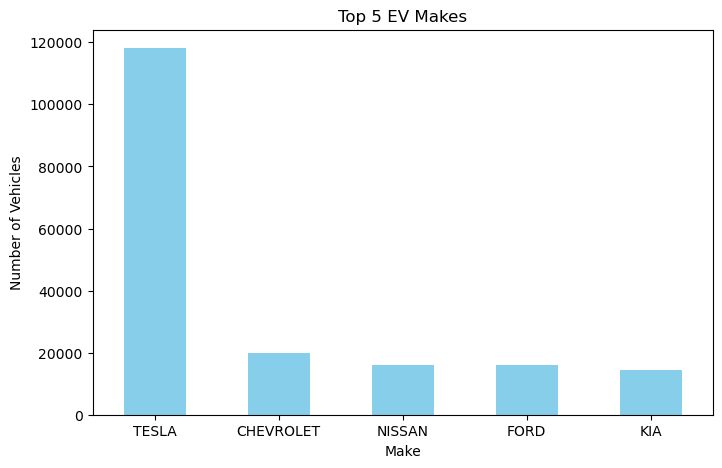

In [49]:
import matplotlib.pyplot as plt

top_makes = df['Make'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_makes.plot(kind='bar', color='skyblue')
plt.title("Top 5 EV Makes")
plt.xlabel("Make")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=0)
plt.show()

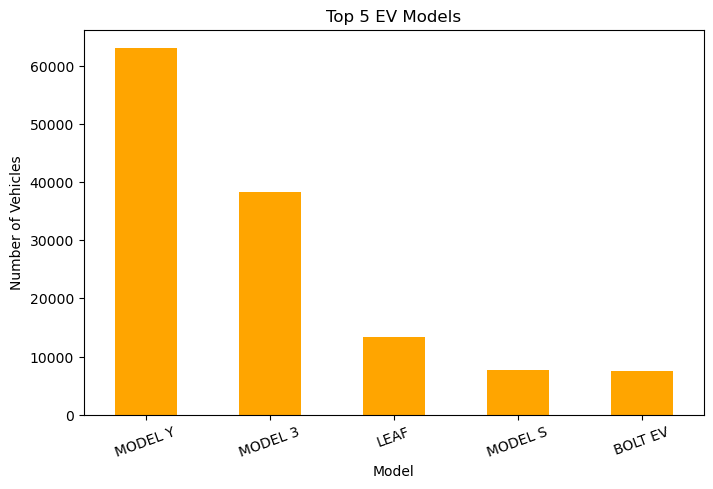

In [50]:
top_models = df['Model'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_models.plot(kind='bar', color='orange')
plt.title("Top 5 EV Models")
plt.xlabel("Model")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=20)
plt.show()

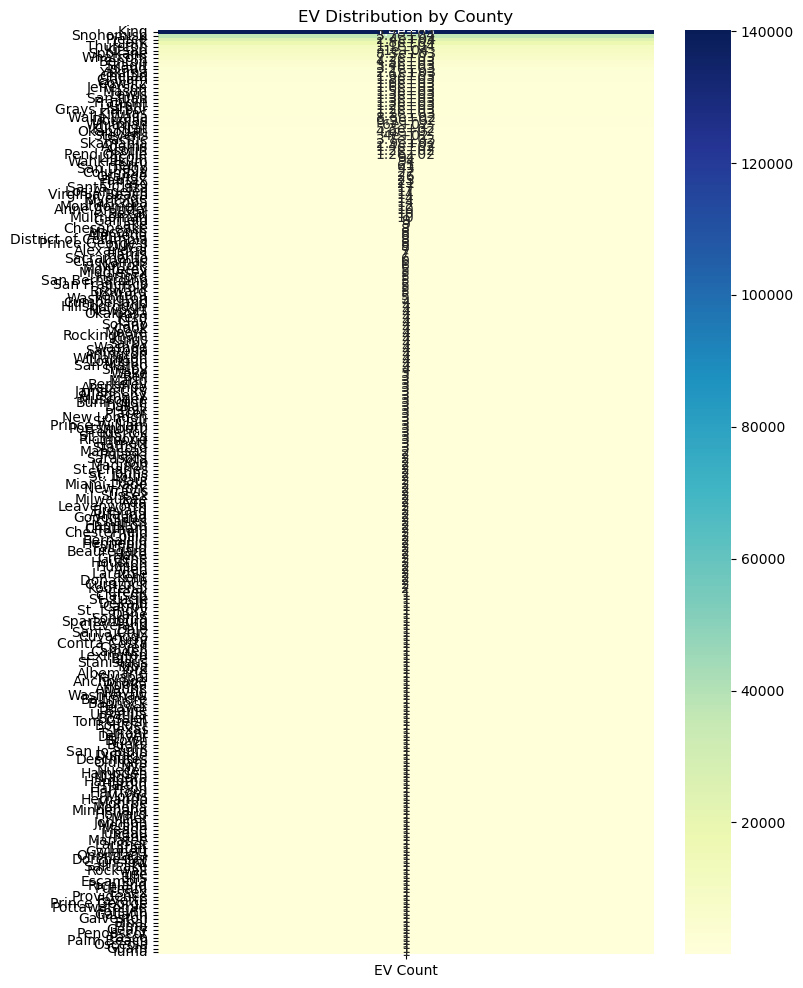

In [51]:
import seaborn as sns

county_counts = df.groupby('County').size().sort_values(ascending=False)

heatmap_df = county_counts.reset_index()
heatmap_df.columns = ['County','EV Count']

plt.figure(figsize=(8,12))
sns.heatmap(
    heatmap_df[['EV Count']],
    annot=True,
    yticklabels=heatmap_df['County'],
    cmap='YlGnBu'
)
plt.title("EV Distribution by County")
plt.show()

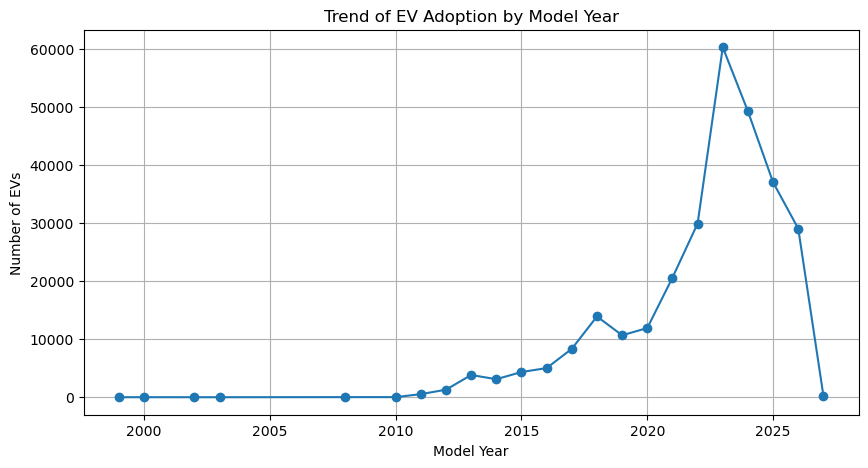

In [52]:
yearly = df.groupby('Model Year').size()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o')
plt.title("Trend of EV Adoption by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of EVs")
plt.grid(True)
plt.show()

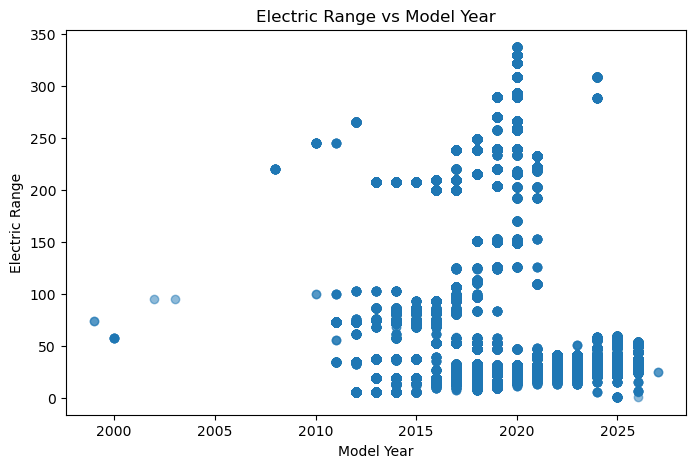

In [53]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Model Year'],
    df['Electric Range'],
    alpha=0.5
)

plt.title("Electric Range vs Model Year")
plt.xlabel("Model Year")
plt.ylabel("Electric Range")
plt.show()

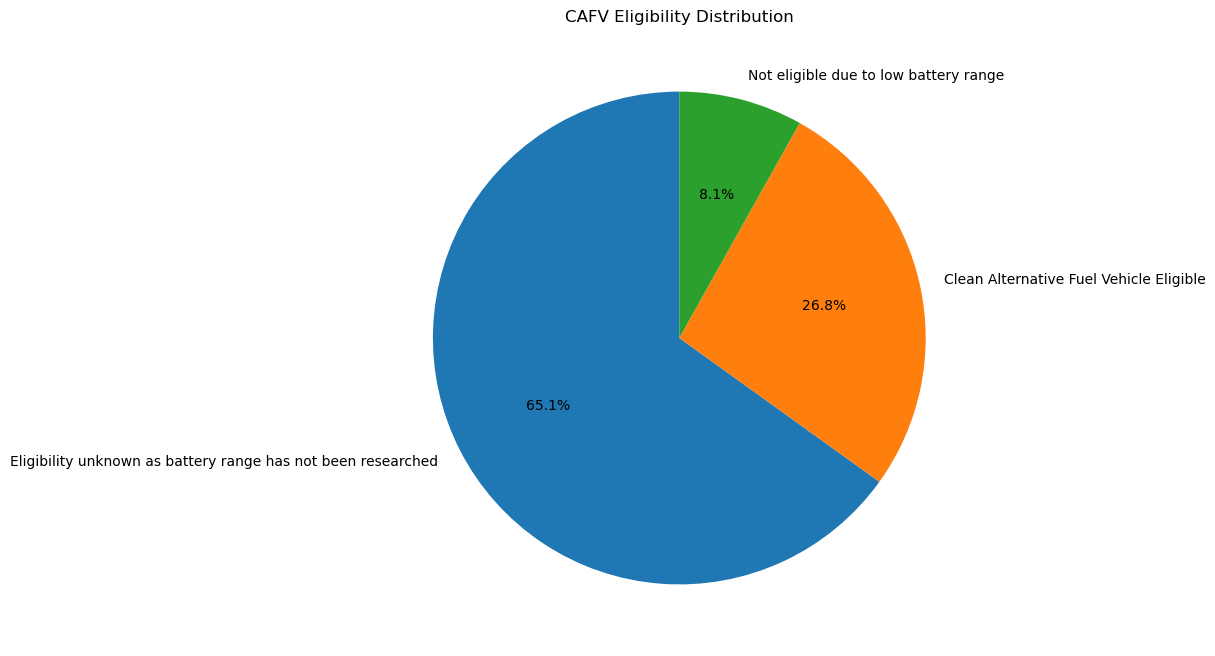

In [54]:
cafv = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    cafv,
    labels=cafv.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("CAFV Eligibility Distribution")
plt.show()

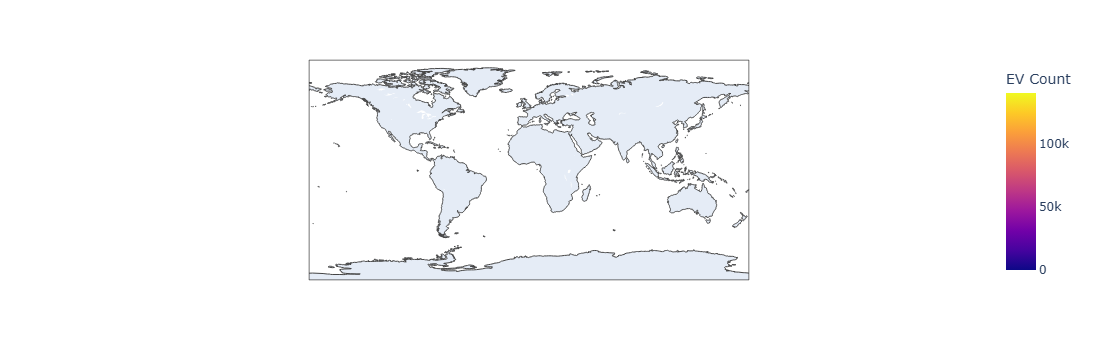

In [56]:
import plotly.express as px

location_counts = df.groupby('County').size().reset_index(name='EV Count')

fig = px.choropleth(
    location_counts,
    locations='County',
    locationmode='USA-states',   # This won't work with county names directly
    color='EV Count'
)

fig.show()

 Linear Regression Model Questions:

1. How can we use Linear Regression to predict the Electric Range of a vehicle?

Linear Regression predicts the Electric Range by finding a mathematical relationship between the target variable (Electric Range) and one or more independent variables such as Model Year, Make, Vehicle Type, and CAFV Eligibility. The model learns from historical data and predicts the electric range for new vehicles.

2. What independent variables (features) can be used to predict Electric Range?

The following features can be used:

Model Year
Make
Model
Electric Vehicle Type
Clean Alternative Fuel Vehicle (CAFV) Eligibility
County (optional)
State (optional)

3. How do we handle categorical variables like Make and Model in regression analysis?

Categorical variables cannot be used directly in Linear Regression. They must first be converted into numerical values using techniques such as:

One-Hot Encoding (recommended)
Label Encoding (less preferred for regression)

For example:

Make	Encoded
Tesla	1 0 0
Nissan	0 1 0
Chevrolet	0 0 1

This allows the regression model to process categorical data correctly.

4. What is the R² score of the model, and what does it indicate about prediction accuracy?

The R² (R-squared) score measures how well the model explains the variation in the target variable.

R² = 1.0 → Perfect prediction
R² = 0.8 → Very good model
R² = 0.5 → Moderate prediction
R² = 0 → No predictive power

A higher R² score indicates better prediction accuracy.

5. How does the Base MSRP influence the Electric Range according to the regression model?

Your dataset does not contain the Base MSRP column, so this relationship cannot be analyzed directly.

If Base MSRP were available:

Higher-priced EVs generally tend to have larger batteries.
Larger batteries usually provide longer electric ranges.
Therefore, Base MSRP often has a positive relationship with Electric Range.


6. What steps are needed to improve the accuracy of the Linear Regression model?

The model's accuracy can be improved by:

Cleaning missing values.
Removing duplicate records.
Encoding categorical variables correctly.
Selecting the most relevant features.
Normalizing or scaling numerical features if required.
Removing outliers.
Using more training data.
Trying advanced models such as Random Forest or XGBoost if Linear Regression performs poorly.


7. Can we use this model to predict the range of new EV models based on their specifications?

Yes.

Once the Linear Regression model is trained, it can predict the electric range of new EV models using their specifications (such as Model Year, Make, Vehicle Type, and CAFV Eligibility). However, the prediction accuracy depends on:

The quality of the training data.
The relevance of the input features.
The performance of the trained model (R² score).

If the new vehicle has characteristics that are very different from those in the training data, the prediction may be less accurate.

Conclusion

This project analyzed the Electric Vehicle (EV) Population dataset to identify trends in EV adoption, vehicle characteristics, and regional distribution. The analysis revealed that certain manufacturers, such as Tesla, dominate the EV market, while a few popular models account for a large share of registrations. The trend by Model Year showed a steady increase in EV adoption, indicating the growing popularity of electric vehicles over time.

The county-wise analysis highlighted that EV registrations are concentrated in specific counties, reflecting regional differences in EV adoption. The CAFV (Clean Alternative Fuel Vehicle) eligibility analysis showed the proportion of eligible and non-eligible vehicles, providing insights into government incentive programs. The visualization of electric range also demonstrated differences in battery performance across various vehicles.

A Linear Regression model was explored to predict Electric Range using available vehicle features. Since the dataset did not include the Base MSRP column, the model relied on other available variables such as Model Year, Make, Model, and Electric Vehicle Type. The study concluded that data preprocessing, feature selection, and proper encoding of categorical variables are essential for improving prediction accuracy.

Overall, the project demonstrates how data visualization and machine learning techniques can provide valuable insights into EV adoption patterns and support data-driven decision-making in the electric vehicle industry.

Appendix


Dataset Used
Electric Vehicle Population Dataset (CSV)
Python Libraries Used
pandas
numpy
matplotlib
seaborn
scikit-learn
plotly (optional)
folium (optional)
Data Preprocessing Steps
Loaded the dataset using Pandas.
Checked for missing values.
Removed duplicate records (if any).
Cleaned column names.
Encoded categorical variables for machine learning.
Selected relevant features for analysis and prediction.
Visualizations Created
Bar Chart – Top 5 EV Makes
Bar Chart – Top 5 EV Models
Heatmap – EV Distribution by County
Line Graph – EV Adoption by Model Year
Scatter Plot – Electric Range vs. Model Year (used because Base MSRP was unavailable)
Pie Chart – CAFV Eligibility Distribution
Geospatial Map – EV Registrations by Vehicle Location (optional)
Machine Learning Model
Algorithm: Linear Regression
Target Variable: Electric Range
Features Used:
Model Year
Make
Model
Electric Vehicle Type
CAFV Eligibility
References
Washington State Electric Vehicle Population Dataset
Pandas Documentation: https://pandas.pydata.org/
Matplotlib Documentation: https://matplotlib.org/
Seaborn Documentation: https://seaborn.pydata.org/
Scikit-learn Documentation: https://scikit-learn.org/

This conclusion and appendix are suitable for inclusion in a Data Analytics/EV Population Analysis project report.